In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os

# Cấu hình hiển thị
%matplotlib inline

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv" # File dữ liệu đa biến đã làm sạch
MODEL_FILE = "../../model/lgbm_model.pkl"                # Lưu model dạng file pickle

# Cột mục tiêu cần dự đoán
TARGET_COL = "Gold" 

# Số bước dự báo (Forecast Horizon)
# 1 nghĩa là dùng thông tin giờ hiện tại (t) để đoán giờ tiếp theo (t+1)
SHIFT_STEPS = 1 

print(f"✅ Đã import thư viện LightGBM version: {lgb.__version__}")

✅ Đã import thư viện LightGBM version: 4.6.0


In [6]:
# 1. Đọc dữ liệu
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    print(f"📂 Dữ liệu gốc: {df.shape}")

    # Bỏ cột Datetime nếu có (LGBM chỉ ăn số)
    if 'Datetime' in df.columns:
        df = df.drop(columns=['Datetime'])

    # ==========================================
    # TẠO CỘT TARGET (NHÃN DỰ BÁO)
    # ==========================================
    # Ý tưởng: Để dự báo giá Vàng giờ sau (t+1), ta lấy cột Gold dịch ngược lên 1 dòng
    # Lúc này: Dòng t sẽ chứa Features(t) và Target(Giá t+1)
    df['Target'] = df[TARGET_COL].shift(-SHIFT_STEPS)

    # Sau khi shift, dòng cuối cùng sẽ bị NaN (vì không có giá tương lai), ta xóa đi
    df.dropna(inplace=True)
    
    print(f"✂️ Dữ liệu sau khi tạo Target: {df.shape}")
    display(df.tail()) # Bạn sẽ thấy cột Target chính là cột Gold của dòng sau đó

📂 Dữ liệu gốc: (7637, 12)
✂️ Dữ liệu sau khi tạo Target: (7636, 12)


,Gold,Silver,Brent,Wheat,USD index,RSI,MACD,MACD_SIGNAL,SMA_50,EMA_20,Returns,Target
7631,0.968698,0.963920,0.220126,0.207436,0.196819,0.642288,0.727089,0.695671,0.968292,0.969252,0.406751,0.957574
7632,0.957574,0.945881,0.205870,0.197652,0.198292,0.490425,0.718339,0.702362,0.968704,0.969626,0.304480,0.963481
7633,0.963481,0.954064,0.208386,0.197652,0.196451,0.541471,0.720577,0.708207,0.969027,0.970542,0.505822,0.964662
7634,0.964662,0.953599,0.189518,0.197652,0.195862,0.551154,0.723091,0.713435,0.969502,0.971487,0.449737,0.968501
7635,0.968501,0.951646,0.181551,0.197652,0.196083,0.582050,0.730465,0.719240,0.970058,0.972717,0.481157,0.961020


In [7]:
# 1. Tách Feature (X) và Target (y)
X = df.drop(columns=['Target']) # Tất cả các cột (Gold, Silver, RSI...) dùng làm đầu vào
y = df['Target']                # Chỉ cột Target dùng làm đầu ra

# 2. Chia theo thời gian (Không được random shuffle!)
# Lấy 80% đầu để học, 20% sau để thi
split_idx = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")

# 3. Tạo Dataset riêng của LightGBM (Giúp train nhanh hơn)
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

📊 Train set: (6108, 11)
📊 Val set:   (1528, 11)


In [8]:
# ==========================================
# THIẾT LẬP THAM SỐ (HYPERPARAMETERS)
# ==========================================
params = {
    'objective': 'regression',  # Bài toán hồi quy (dự báo số thực)
    'metric': 'mse',            # Đánh giá bằng sai số bình phương trung bình
    'boosting_type': 'gbdt',    # Kiểu boosting chuẩn
    'num_leaves': 31,           # Độ phức tạp của cây
    'learning_rate': 0.05,      # Tốc độ học
    'feature_fraction': 0.9,    # Mỗi lần học chỉ nhìn 90% số cột (tránh học vẹt)
    'verbose': 0
}

print("🚀 Bắt đầu Training LGBM...")

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,        # Chạy tối đa 1000 vòng
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Nếu 50 vòng không khá hơn thì dừng
        lgb.log_evaluation(100)                 # In kết quả mỗi 100 vòng
    ]
)

print("✅ Training hoàn tất!")

# Lưu model
if not os.path.exists("model"):
    os.makedirs("model")
joblib.dump(model, MODEL_FILE)
print(f"💾 Đã lưu model tại {MODEL_FILE}")

🚀 Bắt đầu Training LGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Training until validation scores don't improve for 50 rounds
[100]	training's l2: 1.14149e-05	valid_1's l2: 0.0210953
[200]	training's l2: 7.92727e-06	valid_1's l2: 0.0206458
Early stopping, best iteration is:
[166]	training's l2: 8.50823e-06	valid_1's l2: 0.0206135
✅ Training hoàn tất!
💾 Đã lưu model tại ../../model/lgbm_model.pkl


📉 Kết quả đánh giá trên tập Val:
   - RMSE: 0.14357
   - MAE:  0.11964


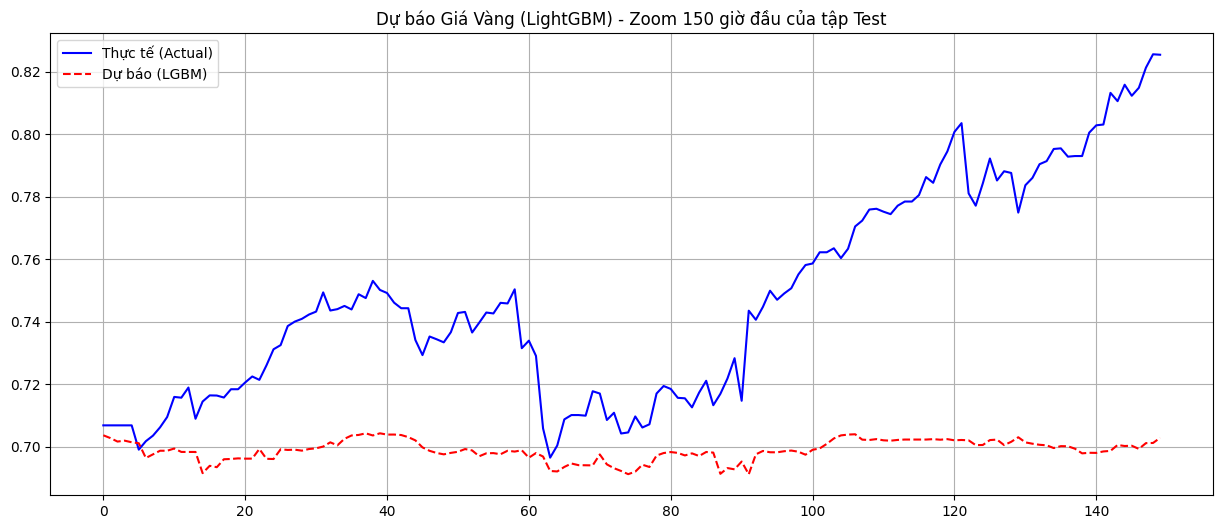

In [9]:
# 1. Dự báo trên tập kiểm thử
y_pred = model.predict(X_val, num_iteration=model.best_iteration)

# 2. Tính sai số
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
print(f"📉 Kết quả đánh giá trên tập Val:")
print(f"   - RMSE: {rmse:.5f}")
print(f"   - MAE:  {mae:.5f}")

# 3. Vẽ biểu đồ (Zoom vào 100 điểm cuối cho dễ nhìn)
plt.figure(figsize=(15, 6))
plt.plot(y_val.values[:150], label='Thực tế (Actual)', color='blue')
plt.plot(y_pred[:150], label='Dự báo (LGBM)', color='red', linestyle='--')
plt.title('Dự báo Giá Vàng (LightGBM) - Zoom 150 giờ đầu của tập Test')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

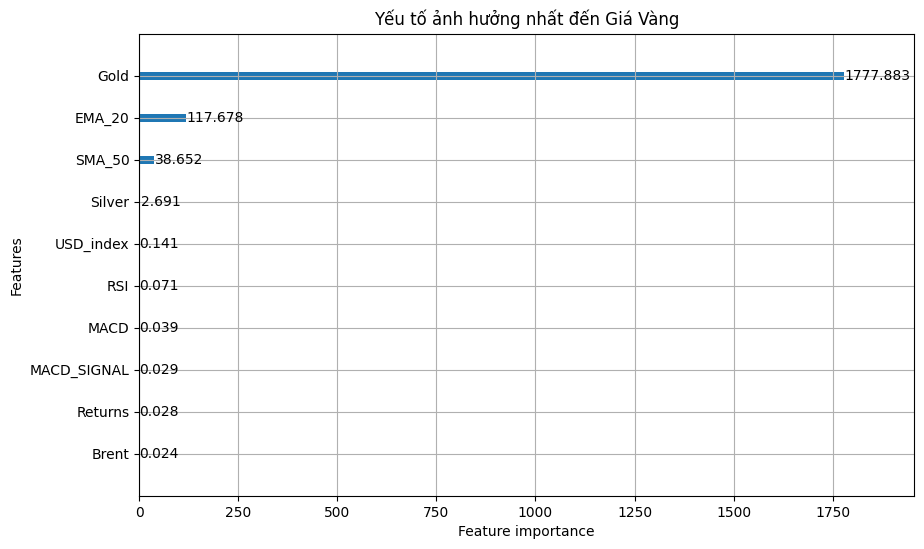

In [10]:
# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain', figsize=(10,6), title='Yếu tố ảnh hưởng nhất đến Giá Vàng')
plt.show()